In [10]:
import numpy as np
import pandas as pd
import re

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [11]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [14]:
df.sample(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
281,flat,godrej nature plus,sector 33,1.4,9333.0,1500.0,Super Built up area 1500(139.35 sq.m.)Carpet area: 1385 sq.ft. (128.67 sq.m.),2,2,3,not available,14.0,NaN,Under Construction,"['Signature Global Infinity Mall Sohna', 'Badshahpur Sohna Rd Hwy', 'Gurjar Samrat Jaipal Khatana Marg', 'K. R. Mangalam University', 'Vidya Niketan Sr Sec School', 'Sanjivani Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']",[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Visitor Parking', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [ ]:
# Work on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

### 1.areaWithType

In [18]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
2690,1.90,2111.0,Carpet area: 2150 (199.74 sq.m.)
2250,2.35,1777.0,Super Built up area 1777(165.09 sq.m.)Built Up area: 1700 sq.ft. (157.94 sq.m.)Carpet area: 1600 sq.ft. (148.64 sq.m.)
3044,0.44,601.0,Carpet area: 601 (55.83 sq.m.)
2067,1.02,2095.0,Super Built up area 2095(194.63 sq.m.)
3224,0.80,1366.0,Super Built up area 1366(126.91 sq.m.)


In [22]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [23]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [24]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [25]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [27]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1117,1.78,flat,2215.0,Super Built up area 2215(205.78 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1650 sq.ft. (153.29 sq.m.),2215.0,2000.0,1650.0
1391,1.80,flat,2030.0,Super Built up area 2030(188.59 sq.m.)Carpet area: 1785 sq.ft. (165.83 sq.m.),2030.0,NaN,1785.0
2138,1.45,house,60.0,Plot area 60(5.57 sq.m.),NaN,NaN,NaN
275,1.20,flat,1848.0,Super Built up area 2250(209.03 sq.m.)Carpet area: 1848 sq.ft. (171.68 sq.m.),2250.0,NaN,1848.0
3155,5.25,flat,4500.0,Super Built up area 4500(418.06 sq.m.),4500.0,NaN,NaN


In [28]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
503,2.65,flat,2019.0,Super Built up area 2045(189.99 sq.m.)Built Up area: 2037 sq.ft. (189.24 sq.m.)Carpet area: 2019 sq.ft. (187.57 sq.m.),2045.0,2037.0,2019.0
4,1.45,flat,1811.0,Super Built up area 1811(168.25 sq.m.)Built Up area: 1711 sq.ft. (158.96 sq.m.)Carpet area: 1611 sq.ft. (149.67 sq.m.),1811.0,1711.0,1611.0
2799,1.35,flat,1500.0,Super Built up area 1530(142.14 sq.m.)Built Up area: 1350 sq.ft. (125.42 sq.m.)Carpet area: 1200 sq.ft. (111.48 sq.m.),1530.0,1350.0,1200.0
2422,1.25,flat,1922.0,Super Built up area 1930(179.3 sq.m.)Built Up area: 1929 sq.ft. (179.21 sq.m.)Carpet area: 1928 sq.ft. (179.12 sq.m.),1930.0,1929.0,1928.0
333,2.12,flat,1365.0,Super Built up area 1365(126.81 sq.m.)Built Up area: 1350 sq.ft. (125.42 sq.m.)Carpet area: 1300 sq.ft. (120.77 sq.m.),1365.0,1350.0,1300.0


In [29]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(532, 7)

In [30]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,NaN,NaN
6,6.95,house,1800.0,Plot area 192(160.54 sq.m.),NaN,NaN,NaN
11,2.40,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
19,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
20,4.75,house,2367.0,Plot area 263(219.9 sq.m.)Built Up area: 261 sq.yards (218.23 sq.m.)Carpet area: 259 sq.yards (216.56 sq.m.),NaN,261.0,259.0


In [31]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(717, 7)

In [32]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 20
facing                 1076
agePossession             1
nearbyLocations         183
furnishDetails          969
features                629
super_built_up_area    1872
built_up_area          2588
carpet_area            1851
dtype: int64

In [34]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [35]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,NaN,NaN
6,6.95,house,1800.0,Plot area 192(160.54 sq.m.),NaN,NaN,NaN
11,2.40,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
19,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
26,4.00,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [36]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [37]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [38]:
#in case of houses,plot area is basically build up area
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [40]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,4500.0,NaN
6,6.95,house,1800.0,Plot area 192(160.54 sq.m.),NaN,192.0,NaN
11,2.40,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.0,NaN
19,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.0,NaN
26,4.00,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.0,NaN


In [41]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [42]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [43]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,4500.0,NaN
6,6.95,house,1800.0,Plot area 192(160.54 sq.m.),NaN,1728.0,NaN
11,2.40,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.0,NaN
19,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.0,NaN
26,4.00,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.0,NaN


In [45]:
# update the original dataframe
df.update(all_nan_df)

In [46]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 20
facing                 1076
agePossession             1
nearbyLocations         183
furnishDetails          969
features                629
super_built_up_area    1872
built_up_area          2012
carpet_area            1851
dtype: int64

### 2.Additional Rooms

In [47]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1561
servant room                                      690
study room                                        243
others                                            223
pooja room                                        167
store room                                        103
study room,servant room                            97
pooja room,servant room                            83
pooja room,study room,servant room,store room      72
pooja room,study room,servant room                 55
servant room,others                                55
pooja room,study room,servant room,others          55
servant room,pooja room                            38
servant room,store room                            31
study room,others                                  26
pooja room,study room                              22
pooja room,store room                              17
pooja room,others                                  16
servant room,

In [48]:
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [49]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
2723,others,0,0,0,0,1
2029,"pooja room,study room,store room",1,0,1,1,0
2780,servant room,0,1,0,0,0
2748,others,0,0,0,0,1
3709,not available,0,0,0,0,0


### 3.agePossession

In [50]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1660
5 to 10 Year Old       579
0 to 1 Year Old        511
10+ Year Old           324
undefined              321
Under Construction      90
Within 6 months         67
Within 3 months         24
Dec 2023                20
By 2023                 17
By 2024                 16
Dec 2024                15
Mar 2024                12
Jan 2024                 7
Jun 2024                 7
Dec 2025                 7
Aug 2023                 6
Oct 2024                 6
Aug 2024                 5
Nov 2023                 5
By 2025                  4
Oct 2023                 4
Sep 2023                 4
Nov 2024                 3
May 2024                 3
Feb 2024                 3
Jul 2024                 3
Jan 2025                 3
Jun 2027                 2
Jul 2027                 2
Mar 2025                 2
Aug 2025                 2
By 2027                  2
Dec 2026                 2
Jul 2025                 2
Sep 2025                 2
Apr 2026      

In [52]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [53]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [54]:
df['agePossession'].value_counts()

agePossession
Relatively New        1660
New Property           602
Moderately Old         579
Old Property           324
Undefined              322
Under Construction     270
Name: count, dtype: int64

### 4.furnishDetails

In [57]:
df.sample(3)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
3185,flat,dlf the skycourt,sector 86,1.35,6998.0,1929.0,Super Built up area 1929(179.21 sq.m.),3,3,1,not available,9.0,North-West,Relatively New,"['Sapphire 83 Mall', 'NH-8, Imt Manesar', 'Rao Bharat Singh International School', 'DPG Institute of Technology', 'Aarvy Healthcare', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'Aapno Ghar', 'National Tennis Academy Sector 98']","['3 Wardrobe', '3 Fan', '4 Light', '3 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",1929.0,NaN,NaN,0,0,0,0,0
2056,flat,kanchanjanga tower,sector 56,1.45,7631.0,1900.0,Super Built up area 1900(176.52 sq.m.),3,3,3+,not available,2.0,North,Moderately Old,"['Sector metro station', 'Sector metro station', 'Sector 54 chowk metro station', 'Sanatan Dharm Mandir', 'Radhakrishna Shani Mandir', 'Icici bank ATM', 'State bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Indusind bank ATM', 'pracksht hospital', 'Arunodaya Deseret Eye Hospital', 'Kriti Hospital', 'Surgicare Hospital Gurgaon', 'Anand Hospital Gurgaon', 'HUDA Office Complex', 'Medisca', 'Apollo Pharmacy', 'Intellion Park', 'International Tech Park', 'HCG CNG Station', 'Heera Fuel Station', 'Hdfc bank and atm', 'State bank of india', 'Kotak mahindra bank', 'Indusind bank', 'Hdfc bank', 'Icici bank', 'Axis bank', 'Hdfc bank & atm', 'Hdfc bank', '222', 'Pizza Hut', 'Wat-a-Burger', 'Burger Singh', 'Bikanerwala', 'Naivedyam Restaurant', 'Clock tower', 'Sushant College of Arts & Architecture', 'Iilm University', 'IILM', 'Ansal Institute of Technology', 'Suncity School']","['3 Wardrobe', '1 Water Purifier', '4 Fan', '1 Exhaust Fan', '3 Geyser', '4 Light', '1 Modular Kitchen', '1 Curtains', '1 Chimney', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant']",1900.0,NaN,NaN,0,0,0,0,0
2556,house,independent,sector 48,5.50,23504.0,2340.0,Plot area 260(217.39 sq.m.),4,4,2,servant room,2.0,North,Relatively New,"['Sri Radhe Krishna Temple', 'Icici bank ATM', 'Standard chartered ATM', 'Best Urologist Atcomplete Family Clinic', 'Wellness Eye Centre', 'Dr. Aruna Kalra', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Neelkanth Health Care', 'Skin Clinic', 'Divine Look Clinic Centre', 'Vishesh Dental', 'Park Hospital Gurgaon', 'Bones Clinic - Orthopaedics', 'Meher Clinic', 'Ekta Hospital', 'Sai Heart and Trauma Center', 'Sai Dharamraj Hospital', 'Samvit Health Care', 'Sanjeevani Hospital Gurgaon', 'Sona Devi Memorial Hospital and Trauma Centre', 'Sukhmani Hospital Pvt. Ltd', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Wembley estate club', 'Genius', 'Apollo Pharmacy', 'Gardian Phar

In [72]:
df.sample(5)[['furnishDetails']]

,furnishDetails
601,[]
2818,"['2 Fan', '1 Fridge', '1 Geyser', '1 Stove', '4 Light', '1 Chimney', '1 Modular Kitchen', '2 AC', '2 TV', '1 Curtains', '1 Bed', '1 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Dining Table', 'No Exhaust Fan', 'No Water Purifier']"
2723,"['3 Fan', '1 Exhaust Fan', '6 Light', '2 AC', '3 Curtains', '1 Modular Kitchen', '3 Wardrobe', 'No Bed', 'No Chimney', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']"
854,NaN
3615,"['1 Water Purifier', '1 Chimney', '1 Modular Kitchen', '4 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine']"


In [59]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [60]:
furnishings_df.shape

(3757, 19)

In [61]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\kushs\AppData\Local\Temp\ipykernel_44856\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [62]:
furnishings_df.sample(5)

,Microwave,TV,Geyser,Wardrobe,Exhaust Fan,Sofa,Water Purifier,Washing Machine,Dining Table,Fridge,Bed,AC,Chimney,Curtains,Light,Stove,Fan,Modular Kitchen
1157,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
817,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,0,13,1
449,0,0,3,2,1,0,0,0,0,0,0,4,1,0,12,1,4,1
1910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [63]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [64]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [65]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

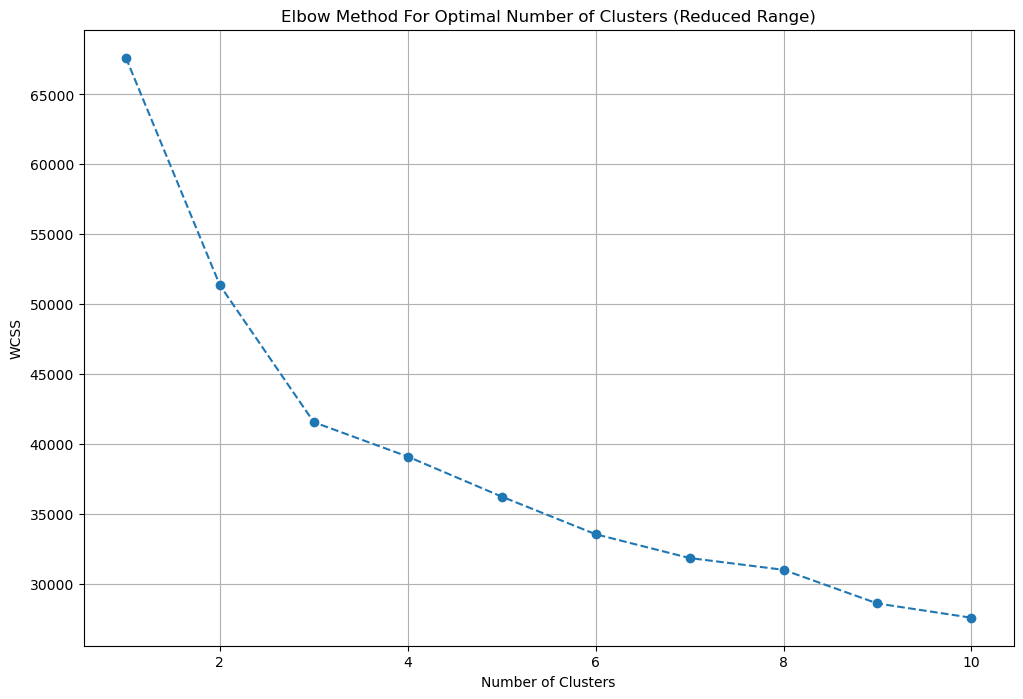

In [66]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [67]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [68]:
df = df.iloc[:,:-18]

In [69]:
df['furnishing_type'] = cluster_assignments

In [70]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
783,"['7 Fan', '1 Fridge', '1 Exhaust Fan', '5 Geyser', '51 Light', '1 Modular Kitchen', '6 AC', '1 Chimney', '4 Wardrobe', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Curtains', 'No Dining Table', 'No Sofa', 'No Stove', 'No TV', 'No Water Purifier']",2
363,"['4 Fan', '1 Exhaust Fan', '1 Geyser', '8 Light', '1 Curtains', '1 Modular Kitchen', '1 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
876,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
1543,[],1
1597,NaN,1


### 5.Features

In [73]:
df[['society','features']].sample(5)

,society,features
2247,trisara our homes 3,NaN
1593,puri emerald bay,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3346,tulip violet,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
2585,ss the leaf,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
3756,shree vardhman flora,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [74]:
df['features'].isnull().sum()

np.int64(629)

In [75]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [76]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [77]:
temp_df = df[df['features'].isnull()]

In [78]:
temp_df.shape

(629, 26)

In [80]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [85]:
df.loc[temp_df.index,'features'] = x.values

In [86]:
df['features'].isnull().sum()

np.int64(484)

In [87]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [88]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [89]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1132,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
1082,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
501,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3451,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0
526,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [90]:
features_binary_df.shape

(3757, 130)

In [91]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

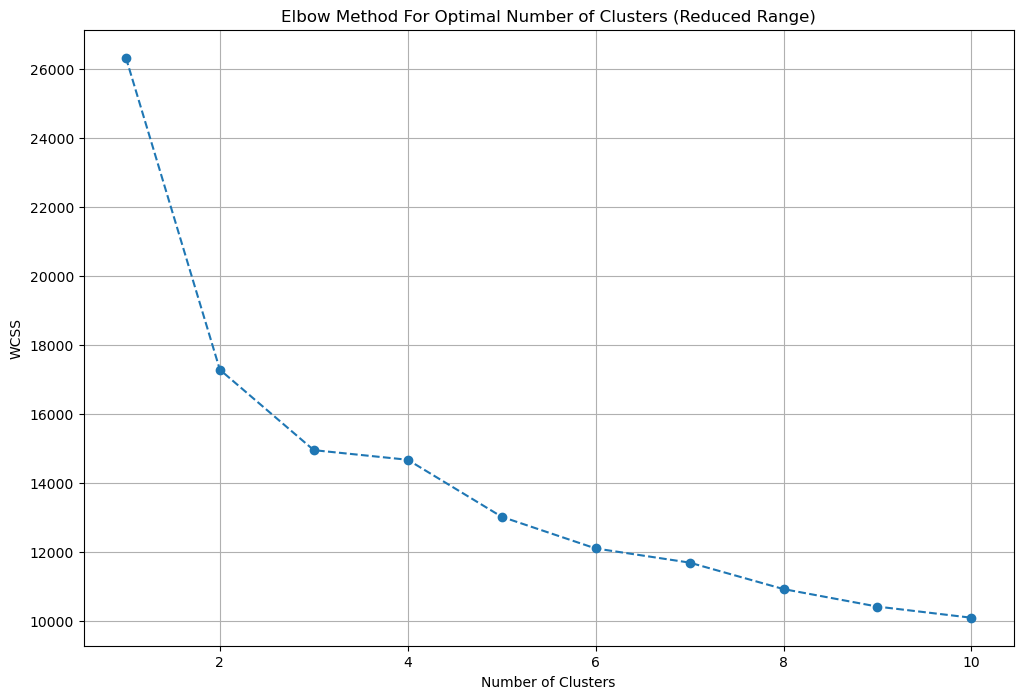

In [92]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
#Above approch of clustering do not work

In [93]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [94]:
df['luxury_score'] = luxury_score

In [95]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,independent,sector 11,4.00,19753.0,2025.0,Built Up area: 225 (188.13 sq.m.)Carpet area: 180 sq.yards (150.5 sq.m.),5,4,1,not available,2.0,North-East,Undefined,"['Palam Vihar Vyapar kendra', 'Palam triangle', 'HUDA Sector 23 Market', 'Ram Mandir', 'Sheetla Mata Mandir', 'Chintapurni Mandir', 'Kalyan Hospital Gurgaon', 'Chirag Hospital Pvt. Ltd', 'Jiya Clinic', 'Dr. Mittal Clinic', ""Dr. Anurag's Child Care Clinic"", 'Yashroop Medical Centre', 'R K Hospital Gurgaon', 'Sneh Hospital Gurgaon', 'Bhardwaj Hospital', 'Dr. Sindhu Clinic', ""DR KAPOOR'S Dental Care and Implant Centre"", 'Jeevan Jyoti Hospital Gurgaon', 'Sarvodya Hospital', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Metro Hospital and Heart Institute Gurgaon', 'GH Gurgaon', 'Children Hospital', 'Dr. Hitesh Dawar', 'Sheetla Clinic', 'Dr. Tomar Clinic', 'Kishor Clinic', 'Dr. Babita Sharma', 'Axis bank', 'Punjab national bank', 'Big Cinemas', ""McDonald's"", 'Moti Mahal', 'Pind Baluchi', 'Cafe Coffee Day', 'Pizza Hut', ""Domino's Pizza"", 'Om Sweets', 'Lieutenant Atul Kataria School', 'THE NORTHCAP UNIVERSITY', 'Chiranjiv Bharati School', 'Masti ki Pathshala Teach India', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station', 'Palam vihar railway station']","['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,225.0,180.0,0,0,0,0,0,1,[],0
1,flat,indiabulls enigma,sector 110,3.30,9850.0,3350.0,Super Built up area 3350(311.23 sq.m.),4,5,3,servant room,7.0,East,Relatively New,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dreamz Mall', 'HUDA Market, Sector 14', 'Dwarka Expressway', 'Delhi Gurgaon Expressway', 'Sanskar Bharti Public School', 'The NorthCap University', 'Manipal Hospital, Gurugram', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'The Oberoi, Gurgaon', 'Fun N Food Village', 'InfinityS Badminton Academy', 'F9 Go Karting Gurgaon', 'SCC Rooftop Drive-In']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",3350.0,NaN,NaN,0,1,0,0,0,1,"[Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Piped-gas, Visitor Parking, Swimming Pool, Park, Internet/wi-fi connectivity, Fitness Centre / GYM, Rain Water Harvesting, Club house / Community Center, Water softening plant]",101
2,flat,puri emerald bay,sector 104,2.30,9387.0,2450.0,Super Built up area 2450(227.61 sq.m.),3,4,3+,servant room,10.0,North-East,Moderately Old,"['Sector-21 Metro Dwarka', 'Gurgaon Dreamz Mall', 'Dwarka Expressway', 'Chauma Road', 'Delhi Public School', 'DPG Degree College', 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Infinity Business Park', 'Park Inn', ""Oyster's Water Park"", 'DLF Golf and Country Club']",[],"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Stora

In [96]:
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [97]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3032,house,independent,sector 12,1.20,14184.0,846.0,Plot area 846(78.6 sq.m.)Built Up area: 846 sq.ft. (78.6 sq.m.),4,4,2,2.0,North,Relatively New,NaN,846.0,NaN,0,0,0,1,0,0,7
1211,flat,laxmi apartment sector 99a gurgaon,sector 99,0.30,4615.0,650.0,Super Built up area 650(60.39 sq.m.)Carpet area: 550 sq.ft. (51.1 sq.m.),2,2,1,4.0,NaN,New Property,650.0,NaN,550.0,0,0,0,0,0,1,44
3218,house,dlf city phase 1,sector 26,3.25,33129.0,981.0,Plot area 109(91.14 sq.m.),3,3,3,2.0,West,Old Property,NaN,981.0,NaN,1,0,0,0,0,1,79
3702,flat,m3m merlin,sector 67,3.40,14418.0,2358.0,Super Built up area 2358(219.07 sq.m.)Carpet area: 1900 sq.ft. (176.52 sq.m.),3,4,3,15.0,South,Relatively New,2358.0,NaN,1900.0,0,1,0,0,0,0,110
2428,house,eldeco mansionz,sector 48,4.95,20599.0,2403.0,Plot area 267(223.25 sq.m.),7,7,3+,2.0,South,Old Property,NaN,2403.0,NaN,1,1,1,1,0,0,145


In [98]:
df.shape

(3757, 23)

In [99]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)